In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Decision Tree Classifier

In [84]:
from sklearn.datasets import load_iris

In [85]:
iris = load_iris()

In [86]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [87]:
X = df.iloc[:,:-1]
y = iris.target

In [88]:
X,y

(     sepal_length  sepal_width  petal_length  petal_width
 0             5.1          3.5           1.4          0.2
 1             4.9          3.0           1.4          0.2
 2             4.7          3.2           1.3          0.2
 3             4.6          3.1           1.5          0.2
 4             5.0          3.6           1.4          0.2
 ..            ...          ...           ...          ...
 145           6.7          3.0           5.2          2.3
 146           6.3          2.5           5.0          1.9
 147           6.5          3.0           5.2          2.0
 148           6.2          3.4           5.4          2.3
 149           5.9          3.0           5.1          1.8
 
 [150 rows x 4 columns],
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33, random_state=42)

In [90]:
from sklearn.tree import DecisionTreeClassifier

In [91]:
model = DecisionTreeClassifier()

In [92]:
model.fit(X_train, y_train)

DecisionTreeClassifier()

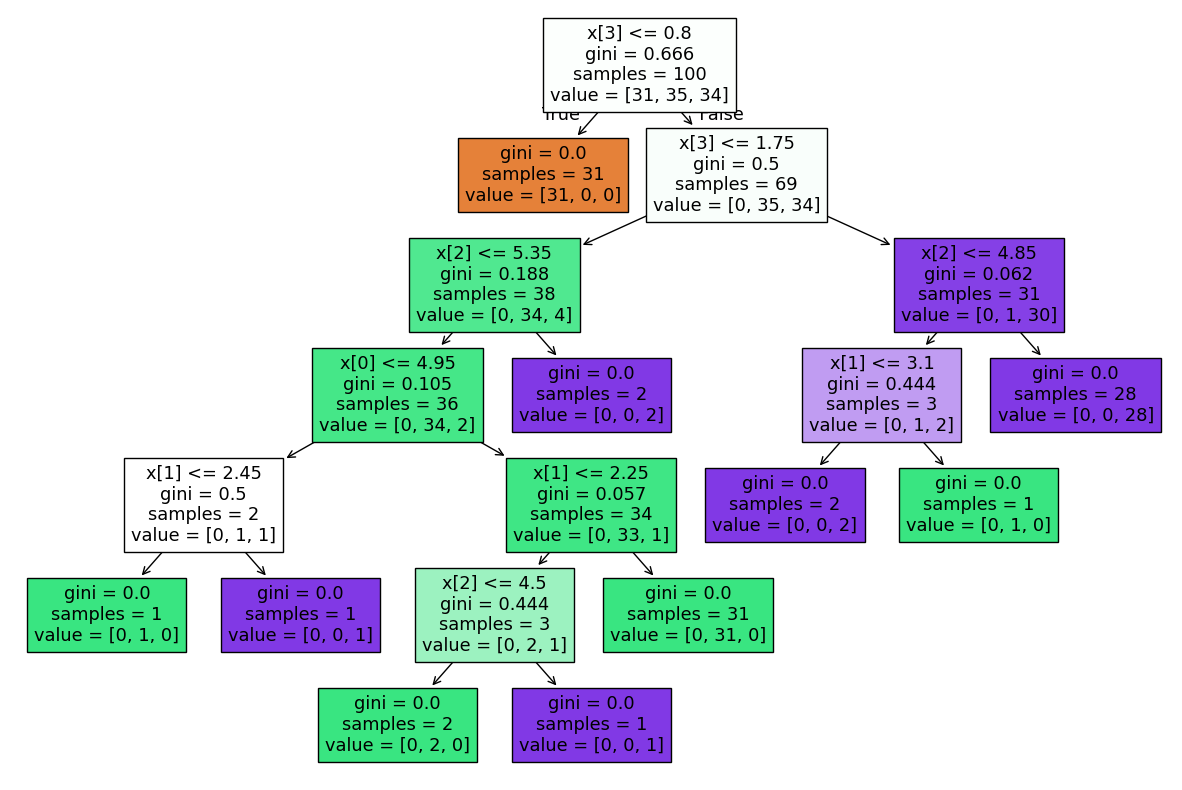

In [93]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(model, filled=True)
plt.show()

In [94]:
y_pred_old = model.predict(X_test)
y_pred_old

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0, 1, 1, 2, 1, 2])

In [95]:
accuracy_score(y_pred_old, y_test)

0.98

### Post-Pruning

In [19]:
#post pruning
new_model = DecisionTreeClassifier(max_depth=2)
new_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2)

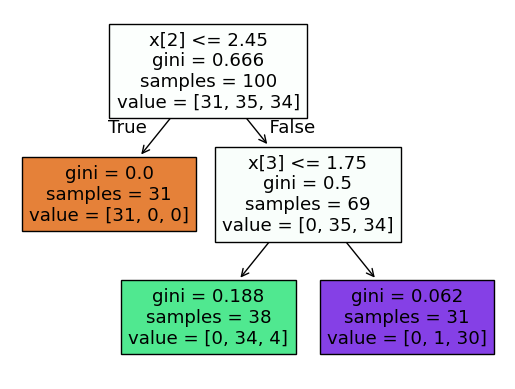

In [20]:
tree.plot_tree(new_model, filled=True)
plt.show()

In [22]:
y_pred = new_model.predict(X_test)
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0, 1, 1, 2, 1, 2])

In [23]:
from sklearn.metrics import accuracy_score, classification_report

In [25]:
score = accuracy_score(y_pred, y_test)
score

0.98

In [27]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.94      0.97        16
           2       0.94      1.00      0.97        15

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



### Pre-Pruning

In [30]:
parameters = {
    'criterion':['gini','entropy','log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5],
    'max_features':['auto','sqrt','log2']
}

In [32]:
from sklearn.model_selection import GridSearchCV

treemodel = DecisionTreeClassifier()
cv = GridSearchCV(treemodel, param_grid=parameters, cv=5, scoring='accuracy')

In [33]:
cv.fit(X_train, y_train)

F:\Anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
150 fits failed out of a total of 450.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
150 fits failed with the following error:
Traceback (most recent call last):
  File "F:\Anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "F:\Anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "F:\Anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
    ~~~~~~~~~

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [34]:
cv.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'max_features': 'log2',
 'splitter': 'best'}

In [38]:
y_pred = cv.predict(X_test)
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 1, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0, 1, 1, 2, 1, 2])

In [39]:
score = accuracy_score(y_pred, y_test)
score

0.96

In [40]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.88      0.94        17
           2       0.88      1.00      0.93        14

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50



### Cross Validation (DT Regressor)

In [42]:
df = pd.read_csv("C:/Users/hp/Downloads/House prediction/data.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,NaN,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [45]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33, random_state=42)

In [47]:
from sklearn.tree import DecisionTreeRegressor
reg = DecisionTreeRegressor()

In [48]:
reg.fit(X_train, y_train)

DecisionTreeRegressor()

In [49]:
y_pred = reg.predict(X_test)
y_pred

array([22. , 27.9,  8.1, 25. , 15.2, 21.6, 18.8, 17.8, 21.4, 19.5, 20.5,
       18.8,  8.3, 21.1, 16.2, 22.8, 20.5, 10.5, 42.3, 14.6, 24.1, 24.4,
       13.6, 20.6, 16.7, 14.9, 22. , 13.5, 20.5, 22.7, 19.8, 22.9, 36.5,
       16.1, 14.4, 13.8, 32.9, 18.7, 22.4, 24.7, 23.1, 37.2, 35.2, 19.9,
       22. , 11. , 15.6, 25. , 23.2, 24.5, 19.1, 35.1, 15.6, 30.1, 43.1,
       20.6, 17.8, 34.9, 22. , 19.4, 27.5, 29. , 30.1, 18.6, 28.4, 14.4,
       12.1, 22.9, 32.5, 14.4, 22.6, 22.8,  8.4, 23.7, 20.6,  5.6, 19.3,
       35.2, 10.4, 13.4, 22. , 16.3, 17.5, 10.5, 20.3, 25.1, 14.1, 23. ,
       22.1, 18.4, 22.6,  8.3, 19.2, 17.5, 18.6, 18.4, 50. , 16.3, 11.8,
       16.3, 17.5, 21.1, 14.6, 20.4, 23.7, 11.7, 20.4, 24.8, 19. , 22.9,
        8.4, 16.3, 22.2, 22.6, 29.9, 16.8, 46. , 17.4, 16.1, 23.7, 17.1,
       24.7,  8.3, 19.1, 24.7, 22.9, 23.2, 37.2, 17.5, 50. , 15.2, 18.6,
       18.6, 27.1, 13.4, 20.2, 19.8, 24.8, 24.5, 17.4, 21.7, 23.5, 19.6,
       14.4,  6.3, 20.1, 13.8, 14.6, 13.5, 48.3, 14

In [50]:
from sklearn.metrics import r2_score
score = r2_score(y_pred, y_test)
score

0.738171992597394

In [51]:
# hyperparameter tuning
parameters = {
    'criterion':['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,6,7,8,10,11,12],
    'max_features':['auto','sqrt','log2']
}
regressor = DecisionTreeRegressor()

In [54]:
reg_cv = GridSearchCV(regressor, param_grid=parameters, cv=5, scoring='neg_mean_squared_error')

In [55]:
reg_cv.fit(X_train, y_train)

F:\Anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
660 fits failed out of a total of 1320.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
440 fits failed with the following error:
Traceback (most recent call last):
  File "F:\Anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "F:\Anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "F:\Anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
    ~~~~~~~~

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [56]:
reg_cv.best_params_

{'criterion': 'poisson',
 'max_depth': 12,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [57]:
y_pred = reg_cv.predict(X_test)

In [58]:
r2_score(y_pred, y_test)

0.41204028677317783

### Random Forest

In [96]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [97]:
y_pred = rf.predict(X_test)

In [98]:
score = accuracy_score(y_pred, y_test)
score

0.98

In [100]:
parameters = {
    'n_estimators': [100, 200, 500],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
    'oob_score' : [True, False],
    'criterion': ['gini', 'entropy']
}

In [104]:
from sklearn.model_selection import RandomizedSearchCV

tree_model = RandomForestClassifier()
cv = RandomizedSearchCV(rf, param_distributions=parameters, n_iter=100, cv=5, verbose=2, random_state=42, n_jobs=-1)

In [105]:
cv.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


F:\Anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
85 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
85 fits failed with the following error:
Traceback (most recent call last):
  File "F:\Anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "F:\Anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "F:\Anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py", line 448, in fit
    raise ValueError("Out of bag estimation only available if bootst

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 500],
                                        'oob_score': [True, False]},
                   random_state=42, verbose=2)

In [106]:
cv.best_params_

{'oob_score': True,
 'n_estimators': 200,
 'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 20,
 'criterion': 'gini',
 'bootstrap': True}

In [107]:
y_pred = cv.predict(X_test)

from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)
score

1.0